# Slinky dynamic simulation: settle under gravity, then pull

This notebook mirrors the setup in `slinky_2D_training_sim.ipynb`, but runs in two phases:

1. The slinky evolves dynamically under gravity until it is approximately settled.
2. The boundary motion is then applied through a `before_step(robot, t)` callback.

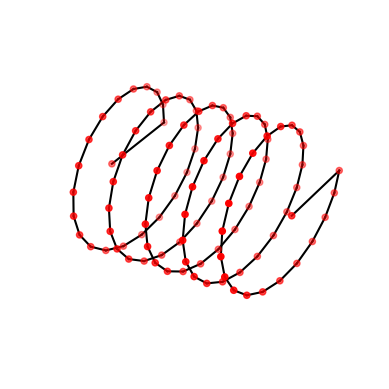

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import dismech

geom = dismech.GeomParams(rod_r0=5e-3, shell_h=0)

material = dismech.Material(
    density=1200,
    youngs_rod=1e7,
    youngs_shell=0,
    poisson_rod=0.5,
    poisson_shell=0,
)

dt = 1e-2
pull_duration = 1.0
pull_speed = 1.0
settle_window = 0.2
max_settle_time = 3.0
speed_tol = 2e-3
required_settled_windows = 3

sim_template = dict(
    static_sim=False,
    two_d_sim=False,
    use_mid_edge=False,
    use_line_search=True,
    line_search_iters=2,
    show_floor=False,
    log_data=True,
    log_step=1,
    dt=dt,
    max_iter=50,
    plot_step=1,
    tol=1e-4,
    ftol=1e-4,
    dtol=1e-2,
)

env = dismech.Environment()
env.add_force('damping', eta=10)
env.add_force('gravity', g=np.array([0.0, 0.0, -9.81]))

geo = dismech.Geometry.from_txt('../tests/resources/slinky/slinky.txt')


In [2]:
def make_robot(total_time):
    sim_params = dismech.SimParams(total_time=total_time, **sim_template)
    robot = dismech.SoftRobot(geom, material, geo, sim_params, env)
    return robot

def enforce_fixed_points(robot, fixed_points):
    return robot.fix_nodes(fixed_points)

def with_total_time(robot, total_time):
    new_params = dismech.SimParams(total_time=total_time, **sim_template)
    new_robot = robot.update()
    new_robot._SoftRobot__sim_params = new_params
    return new_robot


def run_segment(robot, total_time, before_step=None):
    robot = with_total_time(robot, total_time)
    stepper = dismech.ImplicitEulerTimeStepper(robot)
    stepper.before_step = before_step
    return stepper.simulate()


def max_nodal_speed(robot):
    velocities = robot.state.u[:robot.end_node_dof_index].reshape(-1, 3)
    return np.linalg.norm(velocities, axis=1).max()


def append_segment(all_robots, all_times, all_forces, robots, t_arr, Fs, time_offset):
    if not all_robots:
        all_robots.extend(robots)
        all_times.extend(t_arr)
        all_forces.extend(Fs)
    else:
        all_robots.extend(robots[1:])
        all_times.extend([time_offset + t for t in t_arr[1:]])
        all_forces.extend(Fs[1:])


def run_until_settled(robot, window_time, max_total_time, speed_tol, settled_windows):
    all_robots = []
    all_times = []
    all_forces = []
    settle_speeds = []
    stable_count = 0
    elapsed = 0.0

    current_robot = robot
    while elapsed < max_total_time:
        robots, t_arr, _, Fs = run_segment(current_robot, window_time)
        append_segment(all_robots, all_times, all_forces, robots, t_arr, Fs, elapsed)

        current_robot = robots[-1]
        elapsed = all_times[-1]
        speed = max_nodal_speed(current_robot)
        settle_speeds.append(speed)
        print(f'settle time = {elapsed:.3f} s, max nodal speed = {speed:.6e} m/s')

        if speed < speed_tol:
            stable_count += 1
        else:
            stable_count = 0

        if stable_count >= settled_windows:
            break

    settled = stable_count >= settled_windows
    return current_robot, np.array(all_robots, dtype=object), np.array(all_times), np.array(all_forces), np.array(settle_speeds), settled


In [3]:
robot0 = make_robot(total_time=settle_window)

fixed_points = np.array([0, 1, robot0.n_nodes - 2, robot0.n_nodes - 1])

robot0 = enforce_fixed_points(robot0, fixed_points)

end_node_idxs = np.array([robot0.n_nodes - 2, robot0.n_nodes - 1])

settled_robot, settle_robots, settle_t_arr, settle_Fs, settle_speeds, settled = run_until_settled(
    robot0,
    window_time=settle_window,
    max_total_time=max_settle_time,
    speed_tol=speed_tol,
    settled_windows=required_settled_windows,
)

print('Settled:', settled)
print('Equilibrium time used:', settle_t_arr[-1], 's')
print('Final max nodal speed:', settle_speeds[-1])


iter: 1, error: 0.100
iter: 2, error: 0.042
current_time:  0.01
iter: 1, error: 0.150
iter: 2, error: 0.077
current_time:  0.02
iter: 1, error: 0.179
iter: 2, error: 0.094
current_time:  0.03
iter: 1, error: 0.193
iter: 2, error: 0.129
current_time:  0.04
iter: 1, error: 0.199
iter: 2, error: 0.178
iter: 3, error: 0.000
current_time:  0.05
iter: 1, error: 0.200
iter: 2, error: 0.221
iter: 3, error: 0.000
current_time:  0.060000000000000005
iter: 1, error: 0.197
iter: 2, error: 0.249
iter: 3, error: 0.000
current_time:  0.07
iter: 1, error: 0.192
iter: 2, error: 0.257
iter: 3, error: 0.000
current_time:  0.08
iter: 1, error: 0.186
iter: 2, error: 0.250
iter: 3, error: 0.000
current_time:  0.09
iter: 1, error: 0.178
iter: 2, error: 0.232
iter: 3, error: 0.000
current_time:  0.09999999999999999
iter: 1, error: 0.170
iter: 2, error: 0.209
iter: 3, error: 0.000
current_time:  0.10999999999999999
iter: 1, error: 0.162
iter: 2, error: 0.186
iter: 3, error: 0.000
current_time:  0.1199999999999

In [4]:
pull_robot = settled_robot.fix_nodes(end_node_idxs)
pull_displacements = []

def pull_after_settle(robot, t):
    robot = robot.move_nodes(end_node_idxs, [pull_speed * robot.sim_params.dt, 0.0, 0.0])
    pull_displacements.append((t, robot.state.q[robot.end_node_dof_index - 3]))
    return robot

pull_robots, pull_t_local, pull_f_norms, pull_Fs = run_segment(
    pull_robot,
    total_time=pull_duration,
    before_step=pull_after_settle,
)


iter: 1, error: 377.723
iter: 2, error: 58.621
iter: 3, error: 55.302
iter: 4, error: 27.053
iter: 5, error: 13.284
iter: 6, error: 6.563
iter: 7, error: 3.261
iter: 8, error: 1.625
iter: 9, error: 0.812
iter: 10, error: 0.406
iter: 11, error: 0.203
iter: 12, error: 0.101
iter: 13, error: 0.051
iter: 14, error: 0.025
current_time:  0.01
iter: 1, error: 397.598
iter: 2, error: 52.975
iter: 3, error: 60.153
iter: 4, error: 29.547
iter: 5, error: 14.521
iter: 6, error: 7.169
iter: 7, error: 3.558
iter: 8, error: 1.772
iter: 9, error: 0.884
iter: 10, error: 0.442
iter: 11, error: 0.221
iter: 12, error: 0.110
iter: 13, error: 0.055
iter: 14, error: 0.028
current_time:  0.02
iter: 1, error: 401.600
iter: 2, error: 51.601
iter: 3, error: 60.057
iter: 4, error: 29.528
iter: 5, error: 14.517
iter: 6, error: 7.167
iter: 7, error: 3.556
iter: 8, error: 1.771
iter: 9, error: 0.884
iter: 10, error: 0.441
iter: 11, error: 0.221
iter: 12, error: 0.110
iter: 13, error: 0.055
iter: 14, error: 0.028
cur

In [5]:
pull_t_arr = settle_t_arr[-1] + np.array(pull_t_local)

robots = list(settle_robots) + list(pull_robots[1:])
t_arr = np.concatenate([settle_t_arr, pull_t_arr[1:]])
Fs_arr = np.concatenate([settle_Fs, np.array(pull_Fs)[1:]], axis=0)

qs = np.stack([rb.state.q for rb in robots])
vs = np.stack([rb.state.u for rb in robots])

print('Combined trajectory shape:', qs.shape)
print('Combined force history shape:', Fs_arr.shape)


Combined trajectory shape: (261, 407)
Combined force history shape: (261, 407)


In [6]:
options = dismech.AnimationOptions(title='Slinky settle then pull', plot_step=10)
fig = dismech.get_interactive_animation_plotly(robots[-1], t_arr, qs, options)
fig.show()


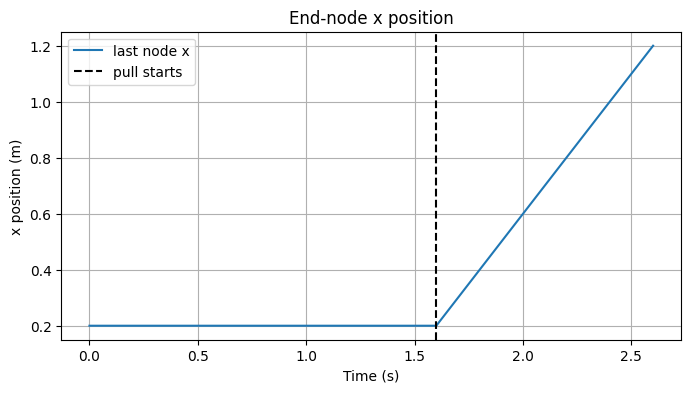

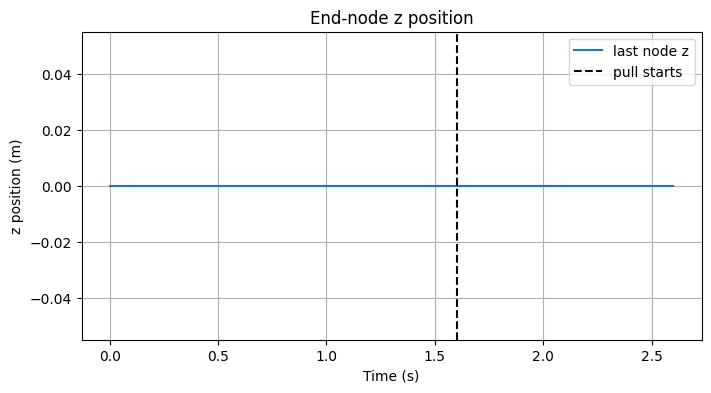

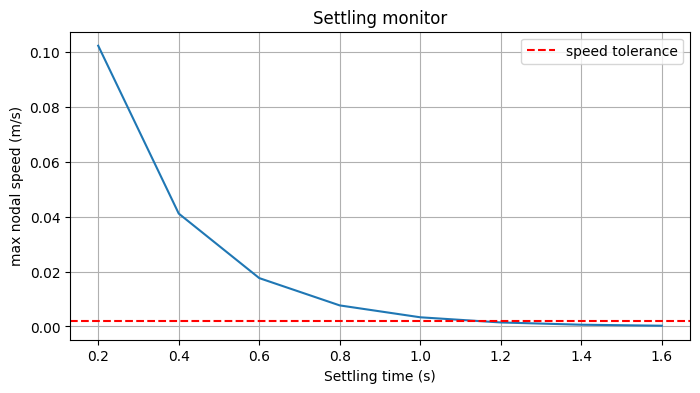

In [7]:
last_node_x = qs[:, robots[-1].end_node_dof_index - 3]
last_node_z = qs[:, robots[-1].end_node_dof_index - 1]

plt.figure(figsize=(8, 4))
plt.plot(t_arr, last_node_x, label='last node x')
plt.axvline(settle_t_arr[-1], color='k', linestyle='--', label='pull starts')
plt.xlabel('Time (s)')
plt.ylabel('x position (m)')
plt.title('End-node x position')
plt.grid(True)
plt.legend()

plt.figure(figsize=(8, 4))
plt.plot(t_arr, last_node_z, label='last node z')
plt.axvline(settle_t_arr[-1], color='k', linestyle='--', label='pull starts')
plt.xlabel('Time (s)')
plt.ylabel('z position (m)')
plt.title('End-node z position')
plt.grid(True)
plt.legend()

plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(settle_speeds) + 1) * settle_window, settle_speeds)
plt.axhline(speed_tol, color='r', linestyle='--', label='speed tolerance')
plt.xlabel('Settling time (s)')
plt.ylabel('max nodal speed (m/s)')
plt.title('Settling monitor')
plt.grid(True)
plt.legend()


27


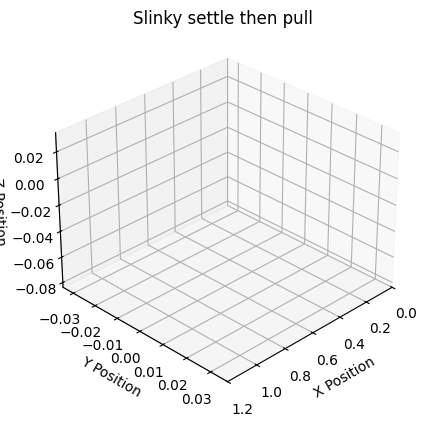

In [ ]:
# # Optional: save the animation if desired.
# ani = dismech.get_animation(robots[-1], t_arr, qs, options)
# ani.save('slinky_settle_then_pull.gif')


In [9]:
# # Training data starts from the settled configuration and includes only the pull trajectory.
# qs = np.stack([rb.state.q for rb in pull_robots])
# Fs_arr = np.array(pull_Fs)
# t_arr = np.array(pull_t_local)

# # save the data so that we don't have to run simulation again
# np.savez('slinky_2D_data_raw.npz', qs=qs, F=Fs_arr, t=t_arr)

In [10]:


# ## filter
# first_idx_of_interest = 1 # ignore the first 100 frames where the F is loggesd as zeros
# last_idx_of_interest = 10 # ignore the last 100 frames where the force decreases
# # filter all force qs to last_idx_of_interest
# q_filtered = qs[first_idx_of_interest:-last_idx_of_interest, :]
# F_filtered = Fs_arr[first_idx_of_interest:-last_idx_of_interest, :]
# t_filtered = t_arr[first_idx_of_interest:-last_idx_of_interest]

# print(q_filtered.shape)
# print(F_filtered.shape)


In [11]:
# num_t = q_filtered.shape[0]

# # original qs format:
# # [all node positions, all thetas]
# # = [x0,y0,z0, x1,y1,z1, ..., x_{N-1},y_{N-1},z_{N-1}, theta0,...,theta_{N-2}]

# positions = q_filtered[:, :pull_robot.end_node_dof_index]
# positions_reshaped = positions.reshape(num_t, pull_robot.n_nodes, 3)

# # first and last nodes
# node0 = positions_reshaped[:, 0, :]
# node_last = positions_reshaped[:, -1, :]

# # centroid of all original nodes
# centroid = np.mean(positions_reshaped, axis=1)

# # reduced state:
# # [x0,y0,z0,theta0, xc,yc,zc,theta1, xlast,ylast,zlast]
# qs_to_train = np.zeros((num_t, 11))
# qs_to_train[:, 0:3] = node0
# qs_to_train[:, 3] = 0.0
# qs_to_train[:, 4] = centroid[:, 0] # x of centroid
# ## y is ignored since it's always zero in 2D
# qs_to_train[:, 6] = centroid[:, 2] # z of centroid
# qs_to_train[:, 7] = 0.0
# qs_to_train[:, 8:11] = node_last

# # BC dofs in reduced state
# idx_b = [0, 1, 2, 3, 7, 8, 9, 10]

# # BC values over time
# xb = np.zeros((num_t, len(idx_b)))
# xb[:, 5:8] = node_last

# # example force target: x,z force on node 0 with zero y
# F_train = np.column_stack([
#     F_filtered[:, 0],
#     np.zeros(num_t),
#     F_filtered[:, 2],
# ])

# # add time (lambdas array) to the training data
# lambdas = np.linspace(0, 1, num_t)


In [12]:
# # add a preceding dimension to indicate that we have one trajectory
# qs_to_train = qs_to_train[np.newaxis, :, :]
# F_train = F_train[np.newaxis, :, :]
# xb = xb[np.newaxis, :, :]
# lambdas = lambdas[np.newaxis, :]
# valid = np.full((qs_to_train.shape[0], qs_to_train.shape[1]), True)

# initial_last_node_x = q_filtered[0, pull_robot.end_node_dof_index - 3]
# final_last_node_x = q_filtered[-1, pull_robot.end_node_dof_index - 3]

# print(f"Initial last node x: {initial_last_node_x:.4f} m")
# print(f"Final last node x: {final_last_node_x:.4f} m")
# print(qs_to_train.shape)
# print(valid.shape)

# np.savez('slinky_2D_train_data_settled_start.npz', qs=qs_to_train, F=F_train, xb=xb, idx_b=idx_b, lambdas=lambdas, valid=valid)


In [13]:
# plt.figure(figsize=(8, 4))
# plt.plot(t_filtered, centroid[:, 0], label='centroid x')
# plt.plot(t_filtered, centroid[:, 1], label='centroid y')
# plt.plot(t_filtered, centroid[:, 2], label='centroid z')
# plt.xlabel('Time since settled state (s)')
# plt.ylabel('Position (m)')
# plt.title('Centroid coordinates saved to training data')
# plt.grid(True)
# plt.legend()

# plt.figure(figsize=(8, 4))
# plt.plot(t_filtered, F_filtered[:, 0], label='Fx on node 0')
# plt.plot(t_filtered, np.zeros_like(t_filtered), label='Fy on node 0')
# plt.plot(t_filtered, F_filtered[:, 2], label='Fz on node 0')
# plt.xlabel('Time since settled state (s)')
# plt.ylabel('Force (N)')
# plt.title('First-node force saved to training data')
# plt.grid(True)
# plt.legend()
